Dataset grezzo: 25646 righe × 208 colonne

--- score_UCLA ---
count   24825.00
mean        5.00
std         1.85
min         3.00
25%         3.00
50%         5.00
75%         6.00
max         9.00
Name: score_UCLA, dtype: float64
Missing: 821 (3.2%)

--- intensita_sm ---
intensita_sm
0     331
1    2506
2    3488
3    5619
4    4796
5    4229
6    2688
7    1183
8     806
Name: count, dtype: int64

Media: 3.80
Missing: 0

--- Distribuzione fasce d'età ---
fascia_eta
16–34     7572
35–54    11257
55+       6802
Name: count, dtype: int64

--- Missing variabili di controllo ---
  gender              : 80 (0.3%)
  education           : 162 (0.6%)
  income_decile       : 1956 (7.6%)

--- Listwise deletion ---
Righe prima : 25646
Righe dopo  : 22962
Rimosse     : 2684 (10.5%)

=== DataFrame finale ===
Shape: (22962, 8)
Paesi presenti: 27

Anteprima:
   paese  intensita_sm  score_UCLA fascia_eta  eta  sesso  education  income
0      1             5        5.00      16–34   32   1.00       4.

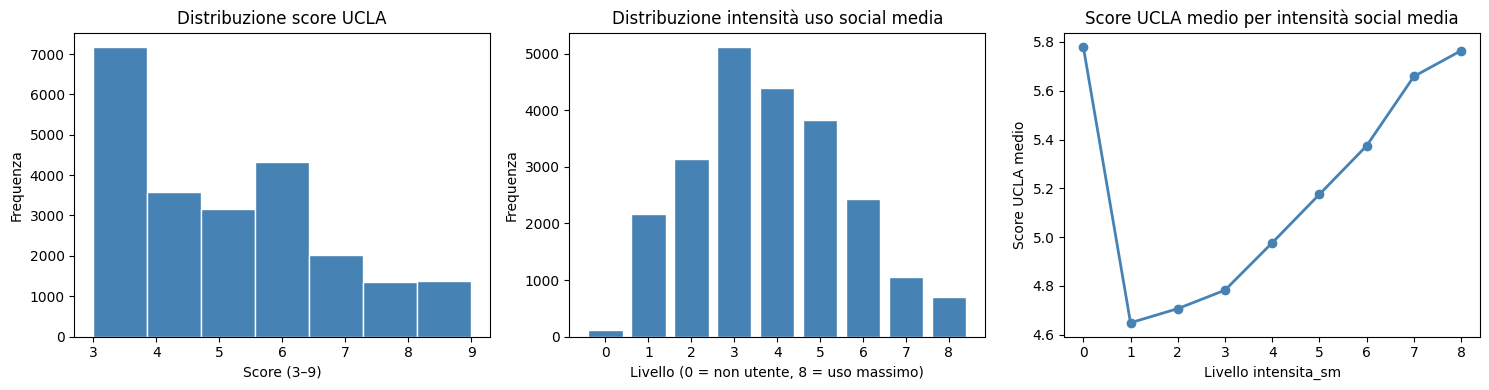


Salvato: output/dataset/eu_ls_clean.csv
Salvato: output/figures/step1_diagnostici.png


In [1]:
# ============================================================
# STEP 1 — Caricamento, pulizia e preparazione EU-LS 2022
# Does Social Media Use Reduce Loneliness?
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
 
os.makedirs('output/dataset', exist_ok=True)
os.makedirs('output/figures', exist_ok=True)
 
# ------------------------------------------------------------------
# 1.1  CARICAMENTO
# ------------------------------------------------------------------
df_raw = pd.read_csv('eu_loneliness_survey_eu27_values.csv', low_memory=False)
print(f"Dataset grezzo: {df_raw.shape[0]} righe × {df_raw.shape[1]} colonne")
 
# ------------------------------------------------------------------
# 1.2  SELEZIONE COLONNE DI INTERESSE
# ------------------------------------------------------------------
COLS = ['loneliness_ucla_a', 'loneliness_ucla_b', 'loneliness_ucla_c',
        'sm_time_a', 'country', 'age', 'gender', 'education', 'income_decile']
 
df = df_raw[COLS].copy()
 
# ------------------------------------------------------------------
# 1.3  COSTRUZIONE score_UCLA
# ------------------------------------------------------------------
for col in ['loneliness_ucla_a', 'loneliness_ucla_b', 'loneliness_ucla_c']:
    df[col] = df[col].replace(999, np.nan)
 
df['score_UCLA'] = df[['loneliness_ucla_a',
                        'loneliness_ucla_b',
                        'loneliness_ucla_c']].sum(axis=1, min_count=3)
 
print("\n--- score_UCLA ---")
print(df['score_UCLA'].describe().round(2))
print(f"Missing: {df['score_UCLA'].isna().sum()} ({df['score_UCLA'].isna().mean()*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.4  COSTRUZIONE intensita_sm
# ------------------------------------------------------------------
df['intensita_sm'] = df['sm_time_a'].replace(999, 0)
 
print("\n--- intensita_sm ---")
print(df['intensita_sm'].value_counts().sort_index())
print(f"\nMedia: {df['intensita_sm'].mean():.2f}")
print(f"Missing: {df['intensita_sm'].isna().sum()}")
 
# ------------------------------------------------------------------
# 1.5  COSTRUZIONE fascia_eta — 3 FASCE                # ← MODIFICATO
# Motivazione: la fascia 75+ (N originale ≈ 525) è troppo piccola
# per confronti robusti. Le due fasce anziane vengono accorpate
# in "55+" (N combinato ≈ 6.200), omogenea alle altre.
# La distinzione teorica rimane: nativi digitali (16–34),
# generazione di transizione (35–54), pre-digitali (55+).
# ------------------------------------------------------------------
bins   = [15, 34, 54, 120]                           # ← MODIFICATO
labels = ['16–34', '35–54', '55+']                   # ← MODIFICATO
 
df['fascia_eta'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
 
print("\n--- Distribuzione fasce d'età ---")
print(df['fascia_eta'].value_counts().sort_index())
 
# ------------------------------------------------------------------
# 1.6  PULIZIA VARIABILI DI CONTROLLO
# ------------------------------------------------------------------
for col in ['gender', 'education', 'income_decile']:
    df[col] = df[col].replace(999, np.nan)
 
print("\n--- Missing variabili di controllo ---")
for col in ['gender', 'education', 'income_decile']:
    n = df[col].isna().sum()
    print(f"  {col:20s}: {n} ({n/len(df)*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.7  LISTWISE DELETION
# ------------------------------------------------------------------
COLONNE_MODELLO = ['score_UCLA', 'intensita_sm', 'age', 'fascia_eta',
                   'gender', 'education', 'income_decile', 'country']
 
n_prima   = len(df)
df_clean  = df.dropna(subset=COLONNE_MODELLO).copy()
n_dopo    = len(df_clean)
 
print(f"\n--- Listwise deletion ---")
print(f"Righe prima : {n_prima}")
print(f"Righe dopo  : {n_dopo}")
print(f"Rimosse     : {n_prima - n_dopo} ({(n_prima - n_dopo)/n_prima*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.8  DATAFRAME FINALE
# ------------------------------------------------------------------
COLONNE_FINALI = ['country', 'intensita_sm', 'score_UCLA',
                  'fascia_eta', 'age', 'gender', 'education', 'income_decile']
 
df_final = df_clean[COLONNE_FINALI].reset_index(drop=True)
df_final.columns = ['paese', 'intensita_sm', 'score_UCLA',
                    'fascia_eta', 'eta', 'sesso', 'education', 'income']
 
print("\n=== DataFrame finale ===")
print(f"Shape: {df_final.shape}")
print(f"Paesi presenti: {df_final['paese'].nunique()}")
print(f"\nAnteprima:\n{df_final.head(5)}")
 
# ------------------------------------------------------------------
# 1.9  GRAFICI DIAGNOSTICI
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
axes[0].hist(df_final['score_UCLA'], bins=7, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione score UCLA')
axes[0].set_xlabel('Score (3–9)')
axes[0].set_ylabel('Frequenza')
 
conteggi = df_final['intensita_sm'].value_counts().sort_index()
axes[1].bar(conteggi.index, conteggi.values, color='steelblue', edgecolor='white')
axes[1].set_title('Distribuzione intensità uso social media')
axes[1].set_xlabel('Livello (0 = non utente, 8 = uso massimo)')
axes[1].set_ylabel('Frequenza')
axes[1].set_xticks(range(9))
 
medie_globali = df_final.groupby('intensita_sm')['score_UCLA'].mean()
axes[2].plot(medie_globali.index, medie_globali.values,
             marker='o', color='steelblue', linewidth=2)
axes[2].set_title('Score UCLA medio per intensità social media')
axes[2].set_xlabel('Livello intensita_sm')
axes[2].set_ylabel('Score UCLA medio')
axes[2].set_xticks(range(9))
 
plt.tight_layout()
fig.savefig('output/figures/step1_diagnostici.png', dpi=150, bbox_inches='tight')
plt.show()
 
# ------------------------------------------------------------------
# 1.10  SALVATAGGIO
# ------------------------------------------------------------------
df_final.to_csv('output/dataset/eu_ls_clean.csv', index=False)
print("\nSalvato: output/dataset/eu_ls_clean.csv")
print("Salvato: output/figures/step1_diagnostici.png")

Dataset: 22962 righe × 8 colonne

=== Statistiche per fascia d'età ===
                n  ucla_media  ucla_std  sm_media  sm_std
fascia_eta                                               
16–34        6561        5.41      1.83      4.58    1.74
35–54       10204        5.04      1.87      3.78    1.70
55+          6197        4.50      1.73      3.15    1.65

=== Statistiche per paese (ordinato per UCLA medio) ===
          n  ucla_media  sm_media
paese                            
18      322        5.47      4.38
8       883        5.37      3.99
14      905        5.35      4.25
19      448        5.35      4.46
12      919        5.34      4.24
24      921        5.29      3.86
16      860        5.11      3.97
9       893        5.11      3.75
27      887        5.08      3.77
5       451        5.06      4.35
4       917        5.06      3.82
25      910        5.06      3.59
6       905        5.05      3.57
1       878        5.04      3.32
2       879        5.01      3.54
11  

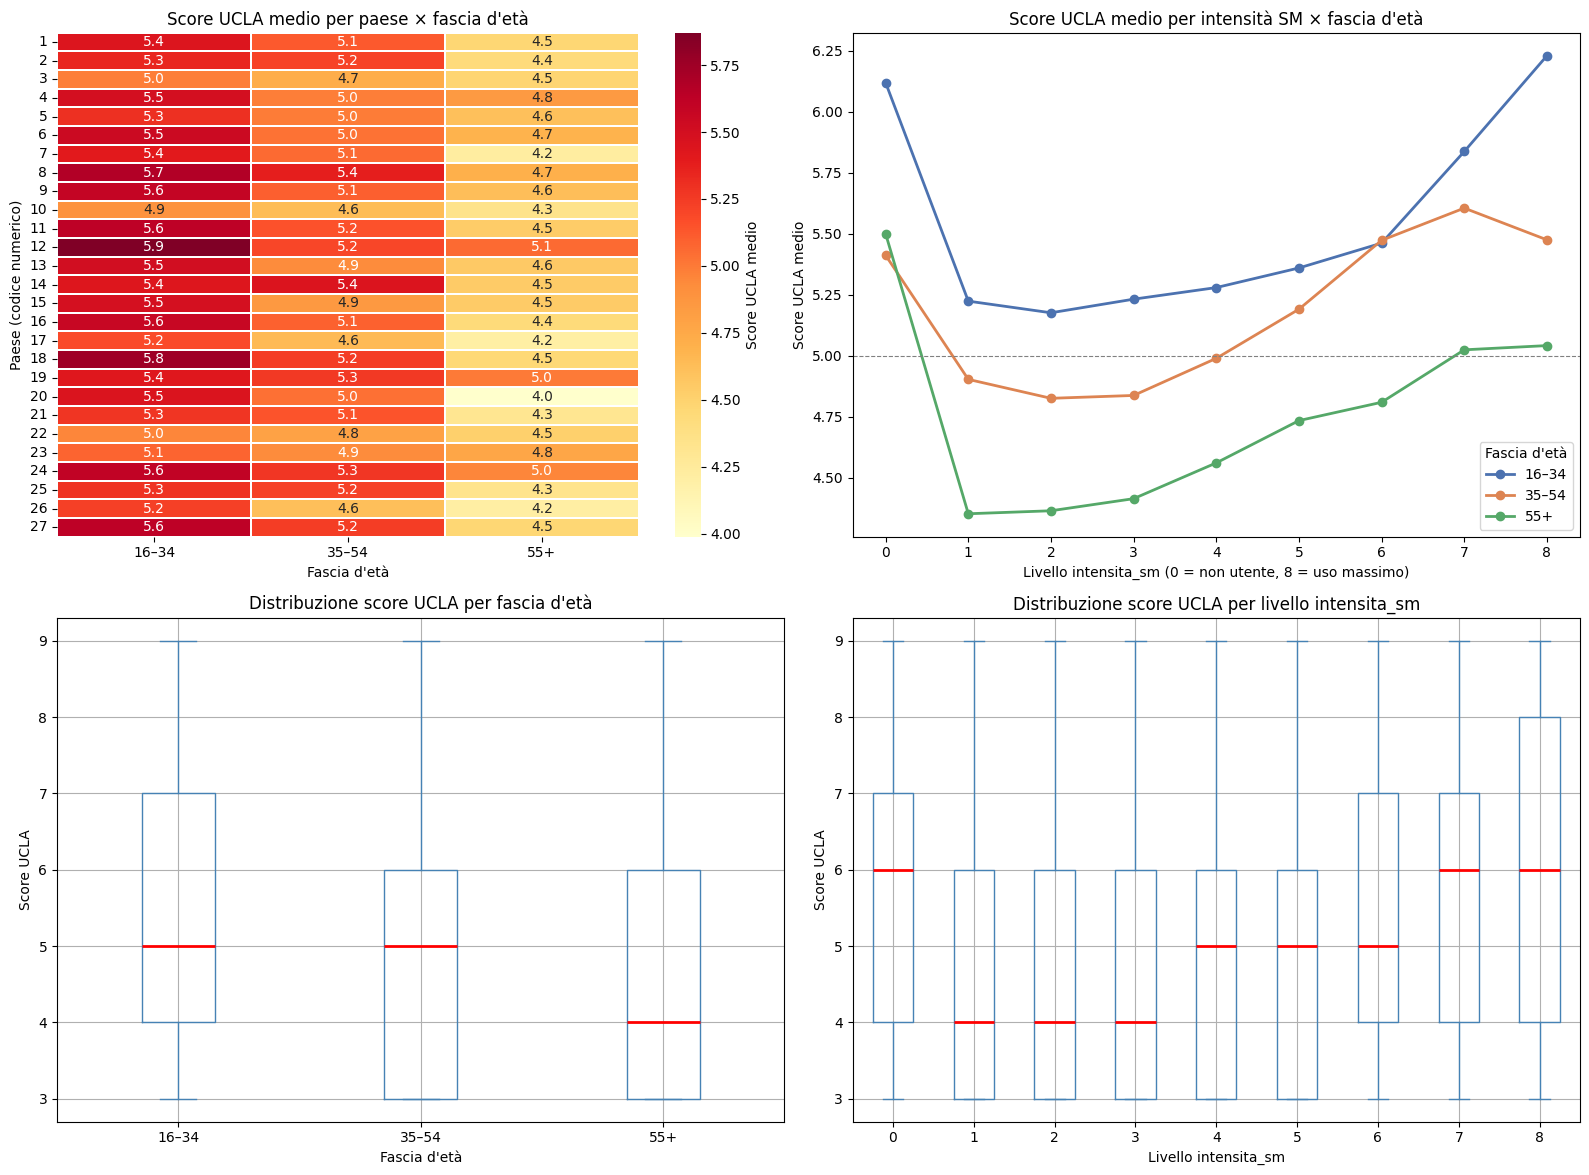


=== Riepilogo EDA ===
Score UCLA medio globale       : 5.00
Intensita_sm media globale     : 3.84
Correlazione Pearson globale   : r = 0.153 (p = 0.0000)
Correlazione Spearman globale  : r = 0.159 (p = 0.0000)

Fascia con UCLA più alto       : 16–34
Fascia con UCLA più basso      : 55+
Fascia con SM più intenso      : 16–34
Fascia con SM meno intenso     : 55+


In [2]:
# ============================================================
# STEP 2 — Analisi esplorativa (EDA)
# Does Social Media Use Reduce Loneliness?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
 
pd.set_option('display.float_format', '{:.2f}'.format)
 
# ------------------------------------------------------------------
# 2.1  CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],  # ← MODIFICATO
                                   ordered=True)
print(f"Dataset: {df.shape[0]} righe × {df.shape[1]} colonne")
 
# ------------------------------------------------------------------
# 2.2  STATISTICHE DESCRITTIVE PER FASCIA D'ETÀ
# ------------------------------------------------------------------
desc = df.groupby('fascia_eta', observed=True).agg(
    n           = ('score_UCLA', 'count'),
    ucla_media  = ('score_UCLA', 'mean'),
    ucla_std    = ('score_UCLA', 'std'),
    sm_media    = ('intensita_sm', 'mean'),
    sm_std      = ('intensita_sm', 'std'),
).round(2)
 
print("\n=== Statistiche per fascia d'età ===")
print(desc)
 
# ------------------------------------------------------------------
# 2.3  STATISTICHE DESCRITTIVE PER PAESE
# ------------------------------------------------------------------
desc_paese = df.groupby('paese', observed=True).agg(
    n          = ('score_UCLA', 'count'),
    ucla_media = ('score_UCLA', 'mean'),
    sm_media   = ('intensita_sm', 'mean'),
).round(2).sort_values('ucla_media', ascending=False)
 
print("\n=== Statistiche per paese (ordinato per UCLA medio) ===")
print(desc_paese)
 
# ------------------------------------------------------------------
# 2.4  CORRELAZIONE BIVARIATA — tutto il campione
# ------------------------------------------------------------------
pearson_r,  pearson_p  = stats.pearsonr(df['intensita_sm'], df['score_UCLA'])
spearman_r, spearman_p = stats.spearmanr(df['intensita_sm'], df['score_UCLA'])
 
print("\n=== Correlazione bivariata (tutto il campione) ===")
print(f"Pearson  r = {pearson_r:.3f}  p = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:.3f}  p = {spearman_p:.4f}")
 
# ------------------------------------------------------------------
# 2.5  CORRELAZIONE PER FASCIA D'ETÀ
# ------------------------------------------------------------------
print("\n=== Correlazione Pearson per fascia d'età ===")
corr_per_fascia = []
for fascia in ['16–34', '35–54', '55+']:                              # ← MODIFICATO
    sub = df[df['fascia_eta'] == fascia]
    r, p = stats.pearsonr(sub['intensita_sm'], sub['score_UCLA'])
    corr_per_fascia.append({'fascia': fascia, 'n': len(sub),
                            'pearson_r': round(r, 3), 'p_value': round(p, 4)})
    print(f"  {fascia:6s}  r = {r:.3f}  p = {p:.4f}  (n={len(sub)})")
 
# ------------------------------------------------------------------
# 2.6  GRAFICI EDA
# ------------------------------------------------------------------
fig = plt.figure(figsize=(16, 12))
 
# --- Fig A: Heatmap UCLA medio per paese × fascia d'età ---
ax1 = fig.add_subplot(2, 2, 1)
pivot = df.groupby(['paese', 'fascia_eta'],
                    observed=True)['score_UCLA'].mean().unstack()
sns.heatmap(pivot, ax=ax1, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.3, cbar_kws={'label': 'Score UCLA medio'})
ax1.set_title("Score UCLA medio per paese × fascia d'età")
ax1.set_xlabel("Fascia d'età")
ax1.set_ylabel('Paese (codice numerico)')
 
# --- Fig B: Line plot UCLA medio per livello intensita_sm × fascia d'età ---
ax2 = fig.add_subplot(2, 2, 2)
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'}  # ← MODIFICATO
for fascia in ['16–34', '35–54', '55+']:                              # ← MODIFICATO
    sub   = df[df['fascia_eta'] == fascia]
    medie = sub.groupby('intensita_sm')['score_UCLA'].mean()
    ax2.plot(medie.index, medie.values, marker='o', linewidth=2,
             label=fascia, color=colori[fascia])
ax2.set_title("Score UCLA medio per intensità SM × fascia d'età")
ax2.set_xlabel('Livello intensita_sm (0 = non utente, 8 = uso massimo)')
ax2.set_ylabel('Score UCLA medio')
ax2.set_xticks(range(9))
ax2.legend(title="Fascia d'età")
ax2.axhline(df['score_UCLA'].mean(), color='gray',
            linestyle='--', linewidth=0.8, label='Media globale')
 
# --- Fig C: Boxplot score UCLA per fascia d'età ---
ax3 = fig.add_subplot(2, 2, 3)
df.boxplot(column='score_UCLA', by='fascia_eta', ax=ax3,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'),
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax3.set_title("Distribuzione score UCLA per fascia d'età")
ax3.set_xlabel("Fascia d'età")
ax3.set_ylabel('Score UCLA')
plt.suptitle('')
 
# --- Fig D: Boxplot score UCLA per livello intensita_sm ---
ax4 = fig.add_subplot(2, 2, 4)
df.boxplot(column='score_UCLA', by='intensita_sm', ax=ax4,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'),
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax4.set_title('Distribuzione score UCLA per livello intensita_sm')
ax4.set_xlabel('Livello intensita_sm')
ax4.set_ylabel('Score UCLA')
plt.suptitle('')
 
plt.tight_layout()
fig.savefig('output/figures/step2_eda.png', dpi=150, bbox_inches='tight')
plt.show()
 
# ------------------------------------------------------------------
# 2.7  RIEPILOGO RISULTATI EDA
# ------------------------------------------------------------------
print("\n=== Riepilogo EDA ===")
print(f"Score UCLA medio globale       : {df['score_UCLA'].mean():.2f}")
print(f"Intensita_sm media globale     : {df['intensita_sm'].mean():.2f}")
print(f"Correlazione Pearson globale   : r = {pearson_r:.3f} (p = {pearson_p:.4f})")
print(f"Correlazione Spearman globale  : r = {spearman_r:.3f} (p = {spearman_p:.4f})")
print("\nFascia con UCLA più alto       :", desc['ucla_media'].idxmax())
print("Fascia con UCLA più basso      :", desc['ucla_media'].idxmin())
print("Fascia con SM più intenso      :", desc['sm_media'].idxmax())
print("Fascia con SM meno intenso     :", desc['sm_media'].idxmin())

Dataset: 22962 righe · 27 paesi

=== OLS — tutto il campione ===
N = 22962  |  R² = 0.0687  |  R² adj = 0.0674

Coefficienti chiave:
  Intercept             β= 5.0272  SE=0.0963  p=0.0000  CI=[4.8384, 5.2159]  ***
  intensita_sm          β= 0.0160  SE=0.0279  p=0.5659  CI=[-0.0387, 0.0708]  
  intensita_sm2         β= 0.0163  SE=0.0034  p=0.0000  CI=[0.0097, 0.0228]  ***
  sesso                 β= 0.1776  SE=0.0238  p=0.0000  CI=[0.1310, 0.2242]  ***
  education             β=-0.0013  SE=0.0146  p=0.9316  CI=[-0.0298, 0.0273]  
  income                β=-0.1145  SE=0.0049  p=0.0000  CI=[-0.1241, -0.1050]  ***

=== OLS — per fascia d'età ===

  Fascia 16–34  (N=6561, R²=0.0651)
    intensita_sm   β=-0.2103  p=0.0002 ***
    intensita_sm²  β=0.0347  p=0.0000 ***

  Fascia 35–54  (N=10204, R²=0.0628)
    intensita_sm   β=-0.0060  p=0.8913 n.s.
    intensita_sm²  β=0.0154  p=0.0037 **

  Fascia 55+  (N=6197, R²=0.0692)
    intensita_sm   β=0.0040  p=0.9363 n.s.
    intensita_sm²  β=0.0095 

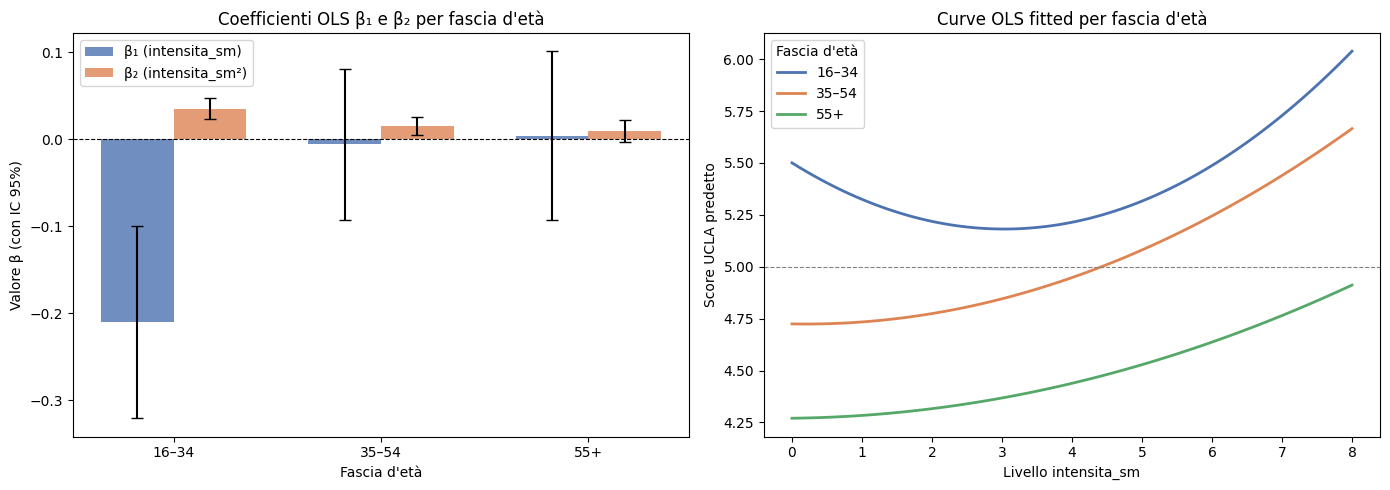

Salvato: output/figures/step3_ols.png


In [3]:
# ============================================================
# STEP 3 — Regressione OLS individuale
# Does Social Media Use Reduce Loneliness?
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from scipy import stats
 
pd.set_option('display.float_format', '{:.4f}'.format)
 
# ------------------------------------------------------------------
# 3.1  CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],  # ← MODIFICATO
                                   ordered=True)
df['intensita_sm2'] = df['intensita_sm'] ** 2
print(f"Dataset: {df.shape[0]} righe · {df['paese'].nunique()} paesi")
 
# ------------------------------------------------------------------
# 3.2  MODELLO OLS — TUTTO IL CAMPIONE
# ------------------------------------------------------------------
formula_full = ('score_UCLA ~ intensita_sm + intensita_sm2 '
                '+ sesso + education + income + C(paese)')
 
model_full = smf.ols(formula_full, data=df).fit(cov_type='HC3')
 
print("\n=== OLS — tutto il campione ===")
print(f"N = {int(model_full.nobs)}  |  R² = {model_full.rsquared:.4f}"
      f"  |  R² adj = {model_full.rsquared_adj:.4f}")
print(f"\nCoefficienti chiave:")
chiavi = ['Intercept', 'intensita_sm', 'intensita_sm2',
          'sesso', 'education', 'income']
for k in chiavi:
    b      = model_full.params[k]
    se     = model_full.bse[k]
    p      = model_full.pvalues[k]
    ci_lo, ci_hi = model_full.conf_int().loc[k]
    sig    = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"  {k:20s}  β={b:7.4f}  SE={se:.4f}  p={p:.4f}  "
          f"CI=[{ci_lo:.4f}, {ci_hi:.4f}]  {sig}")
 
# ------------------------------------------------------------------
# 3.3  MODELLO OLS — SEPARATO PER FASCIA D'ETÀ
# ------------------------------------------------------------------
fasce     = ['16–34', '35–54', '55+']                                # ← MODIFICATO
risultati = {}
 
print("\n=== OLS — per fascia d'età ===")
for fascia in fasce:
    sub = df[df['fascia_eta'] == fascia].copy()
    mod = smf.ols(formula_full, data=sub).fit(cov_type='HC3')
    risultati[fascia] = mod
 
    b1  = mod.params['intensita_sm']
    b2  = mod.params['intensita_sm2']
    p1  = mod.pvalues['intensita_sm']
    p2  = mod.pvalues['intensita_sm2']
    r2  = mod.rsquared
 
    sig1 = '***' if p1<0.001 else ('**' if p1<0.01 else ('*' if p1<0.05 else 'n.s.'))
    sig2 = '***' if p2<0.001 else ('**' if p2<0.01 else ('*' if p2<0.05 else 'n.s.'))
 
    print(f"\n  Fascia {fascia}  (N={int(mod.nobs)}, R²={r2:.4f})")
    print(f"    intensita_sm   β={b1:.4f}  p={p1:.4f} {sig1}")
    print(f"    intensita_sm²  β={b2:.4f}  p={p2:.4f} {sig2}")
 
# ------------------------------------------------------------------
# 3.4  TABELLA COMPARATIVA β PER FASCIA
# ------------------------------------------------------------------
righe = []
for fascia in fasce:
    mod = risultati[fascia]
    for var in ['intensita_sm', 'intensita_sm2']:
        righe.append({
            'fascia'   : fascia,
            'variabile': var,
            'beta'     : round(mod.params[var], 4),
            'SE'       : round(mod.bse[var], 4),
            'p_value'  : round(mod.pvalues[var], 4),
            'CI_low'   : round(mod.conf_int().loc[var, 0], 4),
            'CI_high'  : round(mod.conf_int().loc[var, 1], 4),
            'sig'      : ('***' if mod.pvalues[var]<0.001
                          else ('**' if mod.pvalues[var]<0.01
                          else ('*' if mod.pvalues[var]<0.05 else 'n.s.')))
        })
 
tab = pd.DataFrame(righe)
print("\n=== Tabella comparativa β × fascia d'età ===")
print(tab.to_string(index=False))
tab.to_csv('output/dataset/step3_coefficienti.csv', index=False)
print("\nSalvato: output/dataset/step3_coefficienti.csv")
 
# ------------------------------------------------------------------
# 3.5  VERIFICA H₀ / H₁
# ------------------------------------------------------------------
print("\n=== Verifica ipotesi ===")
print("\nH₀: intensita_sm non associata a score_UCLA in nessuna fascia")
print("H₁: associazione presente e variabile per fascia d'età\n")
 
for fascia in fasce:
    mod  = risultati[fascia]
    p1   = mod.pvalues['intensita_sm']
    p2   = mod.pvalues['intensita_sm2']
    sig  = (p1 < 0.05) or (p2 < 0.05)
    esito = "→ associazione PRESENTE (contro H₀)" if sig else "→ associazione ASSENTE (a favore H₀)"
    print(f"  {fascia:6s}  intensita_sm p={p1:.4f} | intensita_sm² p={p2:.4f}  {esito}")
 
# ------------------------------------------------------------------
# 3.6  GRAFICI
# ------------------------------------------------------------------
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'} # ← MODIFICATO
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# --- Fig A: β₁ e β₂ per fascia con intervalli di confidenza ---
x     = np.arange(len(fasce))
width = 0.35
c_bar = ['#4C72B0', '#DD8452']
 
for i, var in enumerate(['intensita_sm', 'intensita_sm2']):
    betas = [risultati[f].params[var] for f in fasce]
    ci_lo = [risultati[f].conf_int().loc[var, 0] for f in fasce]
    ci_hi = [risultati[f].conf_int().loc[var, 1] for f in fasce]
    yerr  = [[b - lo for b, lo in zip(betas, ci_lo)],
              [hi - b for b, hi in zip(betas, ci_hi)]]
    label = 'β₁ (intensita_sm)' if i == 0 else 'β₂ (intensita_sm²)'
    axes[0].bar(x + i*width, betas, width, yerr=yerr, capsize=4,
                color=c_bar[i], alpha=0.8, label=label)
 
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(fasce)
axes[0].set_title("Coefficienti OLS β₁ e β₂ per fascia d'età")
axes[0].set_xlabel("Fascia d'età")
axes[0].set_ylabel('Valore β (con IC 95%)')
axes[0].legend()
 
# --- Fig B: curve fitted per fascia ---
sm_range = np.linspace(0, 8, 100)
for fascia in fasce:
    mod = risultati[fascia]
    b0  = mod.params['Intercept']
    b1  = mod.params['intensita_sm']
    b2  = mod.params['intensita_sm2']
    sub = df[df['fascia_eta'] == fascia]
    adj = (mod.params.get('sesso', 0)     * sub['sesso'].mean() +
           mod.params.get('education', 0) * sub['education'].mean() +
           mod.params.get('income', 0)    * sub['income'].mean())
    y_pred = b0 + b1*sm_range + b2*sm_range**2 + adj
    axes[1].plot(sm_range, y_pred, linewidth=2, label=fascia,
                 color=colori[fascia])
 
axes[1].axhline(df['score_UCLA'].mean(), color='gray',
                linestyle='--', linewidth=0.8)
axes[1].set_title("Curve OLS fitted per fascia d'età")
axes[1].set_xlabel('Livello intensita_sm')
axes[1].set_ylabel('Score UCLA predetto')
axes[1].set_xticks(range(9))
axes[1].legend(title="Fascia d'età")
 
plt.tight_layout()
fig.savefig('output/figures/step3_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step3_ols.png")

Dataset: 22962 righe · 27 paesi

=== Confronto modelli — tutto il campione ===
R² modello base (solo controlli) : 0.0480
R² modello pieno (+ intensita_sm): 0.0687
ΔR²                              : 0.0207 (2.07%)
F-test contributo intensita_sm   : F = 255.13  p = 0.0000

R² parziale di intensita_sm      : 0.0218 (2.18%)

=== Confronto modelli per fascia d'età ===

  Fascia 16–34  (N=6561)
    R² base → pieno : 0.0513 → 0.0651  (ΔR² = 0.0138)
    R² parziale     : 0.0145 (1.45%)
    F-test          : F = 48.17  p = 0.0000  ***

  Fascia 35–54  (N=10204)
    R² base → pieno : 0.0502 → 0.0628  (ΔR² = 0.0126)
    R² parziale     : 0.0133 (1.33%)
    F-test          : F = 68.30  p = 0.0000  ***

  Fascia 55+  (N=6197)
    R² base → pieno : 0.0644 → 0.0692  (ΔR² = 0.0049)
    R² parziale     : 0.0052 (0.52%)
    F-test          : F = 16.14  p = 0.0000  ***

Salvato: output/dataset/step4_confronto_modelli.csv

=== Verifica ipotesi (confronto modelli) ===
H₀: intensita_sm non aggiunge potere e

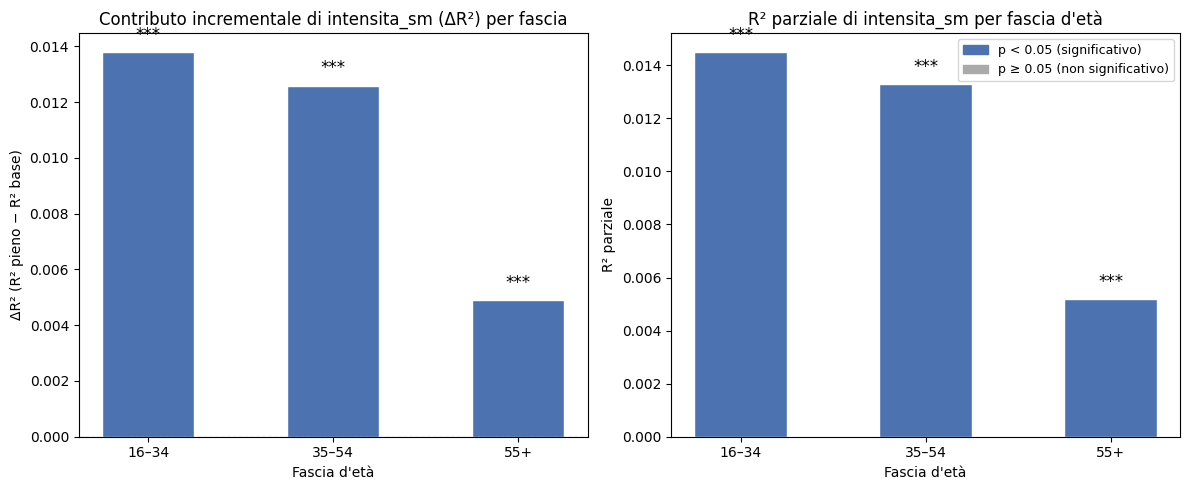

Salvato: output/figures/step4_confronto_modelli.png


In [4]:
# ============================================================
# STEP 4 — Confronto modelli annidati + R² parziale
# Social Media Use and Loneliness in Europe: Does Age Matter?
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from matplotlib.patches import Patch
 
pd.set_option('display.float_format', '{:.4f}'.format)
 
# ------------------------------------------------------------------
# 4.1  CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],  # ← MODIFICATO
                                   ordered=True)
df['intensita_sm2'] = df['intensita_sm'] ** 2
print(f"Dataset: {df.shape[0]} righe · {df['paese'].nunique()} paesi")
 
# ------------------------------------------------------------------
# 4.2  DEFINIZIONE MODELLI
# ------------------------------------------------------------------
formula_base = 'score_UCLA ~ sesso + education + income + C(paese)'
formula_full = ('score_UCLA ~ intensita_sm + intensita_sm2 '
                '+ sesso + education + income + C(paese)')
 
# ------------------------------------------------------------------
# 4.3  CONFRONTO MODELLI — TUTTO IL CAMPIONE
# ------------------------------------------------------------------
m_base = smf.ols(formula_base, data=df).fit(cov_type='HC3')
m_full = smf.ols(formula_full, data=df).fit(cov_type='HC3')
 
r2_base  = m_base.rsquared
r2_full  = m_full.rsquared
delta_r2 = r2_full - r2_base
 
n      = int(m_full.nobs)
k_full = m_full.df_model
f_stat = ((r2_full - r2_base) / 2) / ((1 - r2_full) / (n - k_full - 1))
f_pval = 1 - stats.f.cdf(f_stat, 2, n - k_full - 1)
 
print("\n=== Confronto modelli — tutto il campione ===")
print(f"R² modello base (solo controlli) : {r2_base:.4f}")
print(f"R² modello pieno (+ intensita_sm): {r2_full:.4f}")
print(f"ΔR²                              : {delta_r2:.4f} ({delta_r2*100:.2f}%)")
print(f"F-test contributo intensita_sm   : F = {f_stat:.2f}  p = {f_pval:.4f}")
 
r2_parziale = (r2_full - r2_base) / (1 - r2_base)
print(f"\nR² parziale di intensita_sm      : {r2_parziale:.4f} ({r2_parziale*100:.2f}%)")
 
# ------------------------------------------------------------------
# 4.4  CONFRONTO MODELLI — PER FASCIA D'ETÀ
# ------------------------------------------------------------------
fasce = ['16–34', '35–54', '55+']                                    # ← MODIFICATO
risultati_confronto = []
 
print("\n=== Confronto modelli per fascia d'età ===")
for fascia in fasce:
    sub = df[df['fascia_eta'] == fascia].copy()
    n_f = len(sub)
 
    mb = smf.ols(formula_base, data=sub).fit(cov_type='HC3')
    mf = smf.ols(formula_full, data=sub).fit(cov_type='HC3')
 
    r2_b = mb.rsquared
    r2_f = mf.rsquared
    dr2  = r2_f - r2_b
    r2_p = (r2_f - r2_b) / (1 - r2_b)
 
    k_f  = mf.df_model
    f_s  = ((r2_f - r2_b) / 2) / ((1 - r2_f) / (n_f - k_f - 1))
    f_p  = 1 - stats.f.cdf(f_s, 2, n_f - k_f - 1)
    sig  = '***' if f_p<0.001 else ('**' if f_p<0.01 else ('*' if f_p<0.05 else 'n.s.'))
 
    risultati_confronto.append({
        'fascia'      : fascia,
        'N'           : n_f,
        'R²_base'     : round(r2_b, 4),
        'R²_pieno'    : round(r2_f, 4),
        'ΔR²'         : round(dr2, 4),
        'R²_parziale' : round(r2_p, 4),
        'F'           : round(f_s, 2),
        'p_value'     : round(f_p, 4),
        'sig'         : sig
    })
 
    print(f"\n  Fascia {fascia}  (N={n_f})")
    print(f"    R² base → pieno : {r2_b:.4f} → {r2_f:.4f}  (ΔR² = {dr2:.4f})")
    print(f"    R² parziale     : {r2_p:.4f} ({r2_p*100:.2f}%)")
    print(f"    F-test          : F = {f_s:.2f}  p = {f_p:.4f}  {sig}")
 
tab = pd.DataFrame(risultati_confronto)
tab.to_csv('output/dataset/step4_confronto_modelli.csv', index=False)
print("\nSalvato: output/dataset/step4_confronto_modelli.csv")
 
# ------------------------------------------------------------------
# 4.5  VERIFICA H₀ / H₁
# ------------------------------------------------------------------
print("\n=== Verifica ipotesi (confronto modelli) ===")
print("H₀: intensita_sm non aggiunge potere esplicativo in nessuna fascia")
print("H₁: intensita_sm aggiunge potere esplicativo e in misura variabile per fascia\n")
 
for r in risultati_confronto:
    esito = ("→ contributo SIGNIFICATIVO (contro H₀)"
             if r['p_value'] < 0.05
             else "→ contributo NON significativo (a favore H₀)")
    print(f"  {r['fascia']:6s}  ΔR²={r['ΔR²']:.4f}  R²parz={r['R²_parziale']:.4f}"
          f"  p={r['p_value']:.4f} {r['sig']}  {esito}")
 
# ------------------------------------------------------------------
# 4.6  GRAFICI
# ------------------------------------------------------------------
colori_sig = ['#4C72B0' if r['p_value'] < 0.05 else '#AAAAAA'
              for r in risultati_confronto]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Fig A: ΔR² per fascia
delta_vals = [r['ΔR²'] for r in risultati_confronto]
bars = axes[0].bar(fasce, delta_vals, color=colori_sig, edgecolor='white', width=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title("Contributo incrementale di intensita_sm (ΔR²) per fascia")
axes[0].set_xlabel("Fascia d'età")
axes[0].set_ylabel('ΔR² (R² pieno − R² base)')
for bar, r in zip(bars, risultati_confronto):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0003,
                 r['sig'], ha='center', va='bottom', fontsize=12)
 
# Fig B: R² parziale per fascia
rp_vals = [r['R²_parziale'] for r in risultati_confronto]
bars2 = axes[1].bar(fasce, rp_vals, color=colori_sig, edgecolor='white', width=0.5)
axes[1].set_title("R² parziale di intensita_sm per fascia d'età")
axes[1].set_xlabel("Fascia d'età")
axes[1].set_ylabel('R² parziale')
for bar, r in zip(bars2, risultati_confronto):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0003,
                 r['sig'], ha='center', va='bottom', fontsize=12)
 
legenda = [Patch(color='#4C72B0', label='p < 0.05 (significativo)'),
           Patch(color='#AAAAAA', label='p ≥ 0.05 (non significativo)')]
axes[1].legend(handles=legenda, fontsize=9)
 
plt.tight_layout()
fig.savefig('output/figures/step4_confronto_modelli.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4_confronto_modelli.png")

Dataset: 22962 righe · 31 feature totali
Feature individuali: ['intensita_sm', 'intensita_sm2', 'sesso', 'education', 'income']
Dummies paese: 26

=== RF — tutto il campione ===
  MAE  = 1.5217
  RMSE = 1.7947

=== RF — per fascia d'età ===

  Fascia 16–34  (N_train=5248, N_test=1313)
    MAE = 1.4730  |  RMSE = 1.7772
    Top 5 permutation importance:
      income                  0.0317
      education               0.0113
      intensita_sm2           0.0073
      intensita_sm            0.0053
      sesso                   0.0033

  Fascia 35–54  (N_train=8163, N_test=2041)
    MAE = 1.5256  |  RMSE = 1.8015
    Top 5 permutation importance:
      income                  0.0589
      intensita_sm            0.0113
      intensita_sm2           0.0112
      paese_26                0.0032
      sesso                   0.0028

  Fascia 55+  (N_train=4957, N_test=1240)
    MAE = 1.4131  |  RMSE = 1.7180
    Top 5 permutation importance:
      income                  0.0653
      sesso 

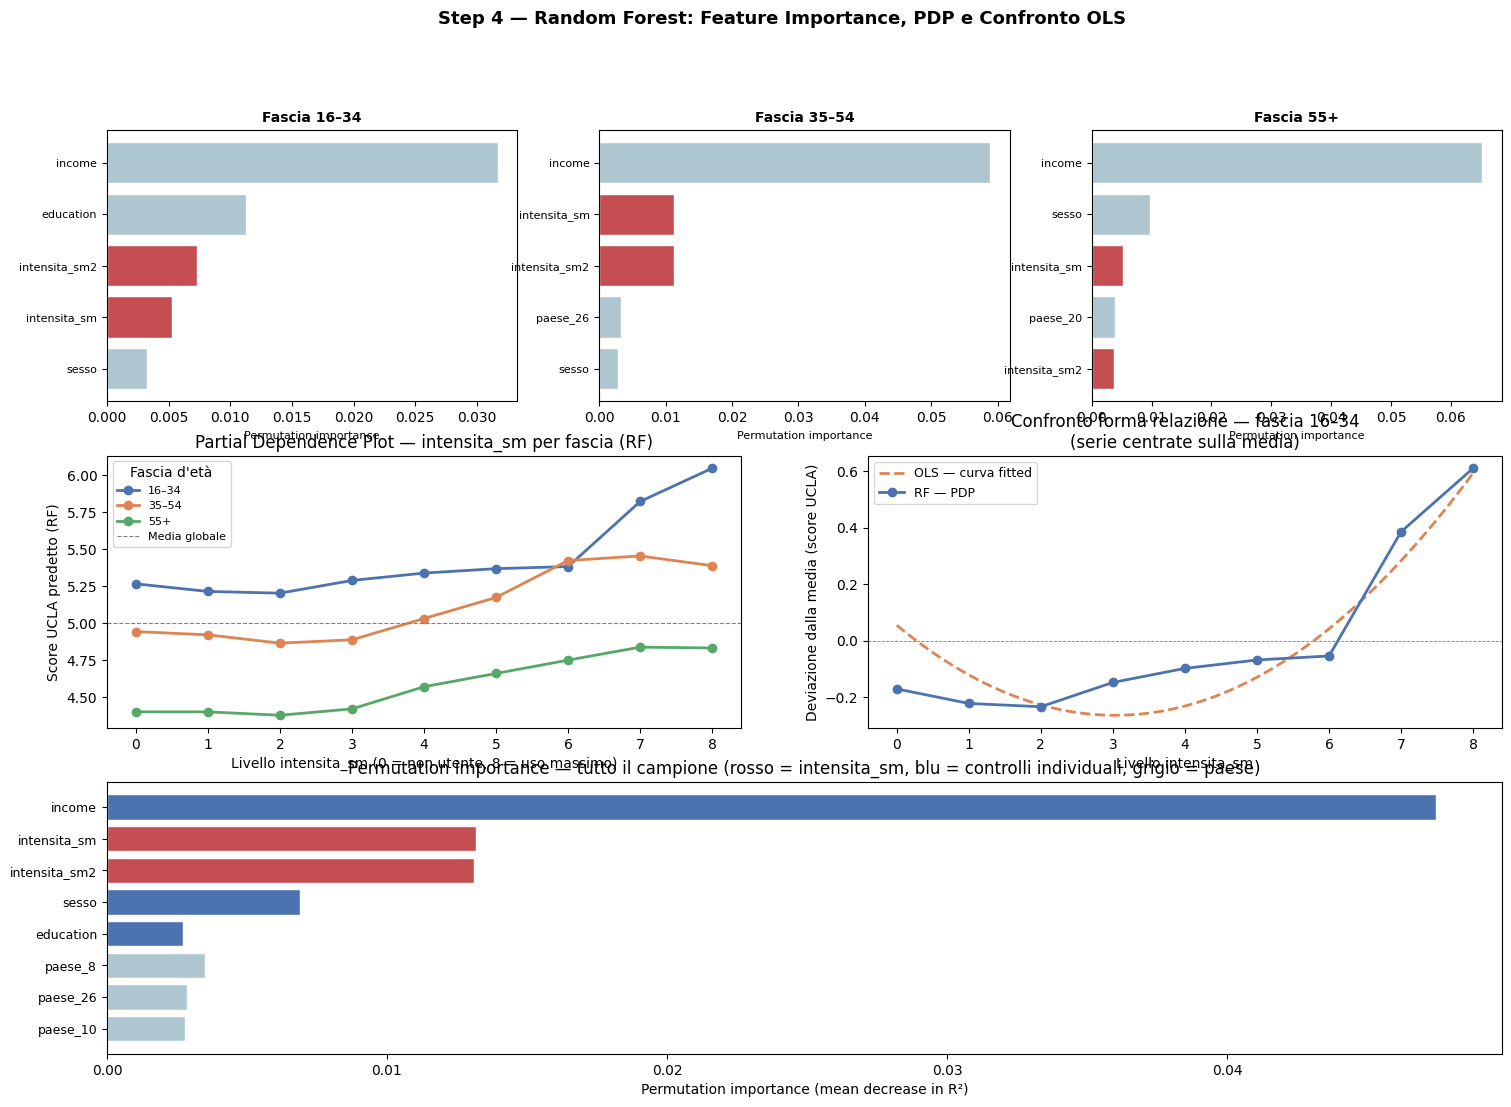


Salvato: output/figures/step4_rf.png


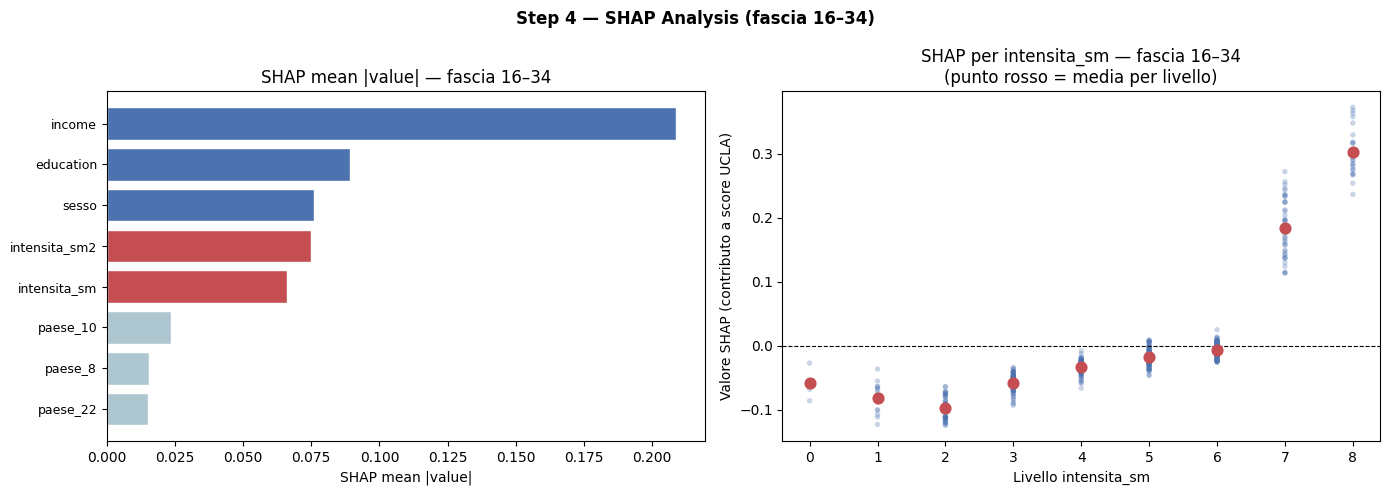

Salvato: output/figures/step4_shap.png

RIEPILOGO STEP 4

RF tutto il campione — MAE=1.5217  RMSE=1.7947

R² basso atteso (come OLS): la solitudine è influenzata da fattori
non osservabili (personalità, storia, eventi di vita).

Funzione del RF in questo progetto:
  → Valida la struttura dell'effetto (importanza relativa delle feature)
  → Cattura la forma a U senza imporla (PDP vs curva OLS: accordo?)
  → Triangolazione metodologica classico+ML


In [5]:
# ============================================================
# STEP 4 — Random Forest (ML supervisionato)
# Does Social Media Use Reduce Loneliness?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
 
pd.set_option('display.float_format', '{:.4f}'.format)
 
# ------------------------------------------------------------------
# 4.1  CARICAMENTO E PREPARAZIONE FEATURE
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],  # ← MODIFICATO
                                   ordered=True)
df['intensita_sm2'] = df['intensita_sm'] ** 2
 
paese_dummies = pd.get_dummies(df['paese'], prefix='paese', drop_first=True)
 
FEATURES = ['intensita_sm', 'intensita_sm2', 'sesso', 'education', 'income']
X_base   = pd.concat([df[FEATURES], paese_dummies], axis=1).astype(float)
y        = df['score_UCLA']
 
fasce  = ['16–34', '35–54', '55+']                                   # ← MODIFICATO
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'} # ← MODIFICATO
 
print(f"Dataset: {df.shape[0]} righe · {X_base.shape[1]} feature totali")
print(f"Feature individuali: {FEATURES}")
print(f"Dummies paese: {paese_dummies.shape[1]}")
 
# ------------------------------------------------------------------
# 4.2  MODELLO RF — TUTTO IL CAMPIONE
# ------------------------------------------------------------------
print("\n=== RF — tutto il campione ===")
 
X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_base, y, test_size=0.20, random_state=42)
 
rf_full = RandomForestRegressor(
    n_estimators=200, max_features='sqrt',
    min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_full.fit(X_tr_full, y_tr_full)
 
y_pred_full = rf_full.predict(X_te_full)
mae_full    = mean_absolute_error(y_te_full, y_pred_full)
rmse_full   = np.sqrt(mean_squared_error(y_te_full, y_pred_full))
 
print(f"  MAE  = {mae_full:.4f}")
print(f"  RMSE = {rmse_full:.4f}")
 
# ------------------------------------------------------------------
# 4.3  MODELLO RF — SEPARATO PER FASCIA D'ETÀ
# ------------------------------------------------------------------
print("\n=== RF — per fascia d'età ===")
 
modelli  = {}
metriche = []
perm_imp = {}
 
for fascia in fasce:
    mask = df['fascia_eta'] == fascia
    X_f  = X_base[mask].reset_index(drop=True)
    y_f  = y[mask].reset_index(drop=True)
 
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_f, y_f, test_size=0.20, random_state=42)
 
    rf = RandomForestRegressor(
        n_estimators=200, max_features='sqrt',
        min_samples_leaf=20, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    modelli[fascia] = (rf, X_tr, X_te, y_tr, y_te)
 
    y_pred = rf.predict(X_te)
    mae    = mean_absolute_error(y_te, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
 
    metriche.append({'Fascia': fascia, 'N_train': len(X_tr),
                     'N_test': len(X_te),
                     'MAE':    round(mae, 4),
                     'RMSE':   round(rmse, 4)})
 
    perm = permutation_importance(
        rf, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)
    perm_imp[fascia] = pd.Series(perm.importances_mean, index=X_base.columns)
 
    top5 = perm_imp[fascia].nlargest(5)
    print(f"\n  Fascia {fascia}  (N_train={len(X_tr)}, N_test={len(X_te)})")
    print(f"    MAE = {mae:.4f}  |  RMSE = {rmse:.4f}")
    print("    Top 5 permutation importance:")
    for feat, imp in top5.items():
        print(f"      {feat:22s}  {imp:.4f}")
 
# ------------------------------------------------------------------
# 4.4  TABELLA METRICHE (Tab. 2)
# ------------------------------------------------------------------
tab_metriche = pd.DataFrame(metriche)
print("\n=== Tab. 2 — MAE e RMSE per fascia ===")
print(tab_metriche.to_string(index=False))
tab_metriche.to_csv('output/dataset/step4_metriche.csv', index=False)
print("\nSalvato: output/dataset/step4_metriche.csv")
 
# ------------------------------------------------------------------
# 4.5  CONFRONTO OLS × RF (Tab. comparativa)
# ------------------------------------------------------------------
ols_tab = pd.read_csv('output/dataset/step3_coefficienti.csv')
ols_sm  = ols_tab[ols_tab['variabile'].isin(['intensita_sm', 'intensita_sm2'])]
 
print("\n=== Tab. comparativa — OLS vs RF per fascia ===")
righe_conf = []
for fascia in fasce:
    sub  = ols_sm[ols_sm['fascia'] == fascia]
    sig1 = sub[sub['variabile'] == 'intensita_sm']['sig'].values[0]
    sig2 = sub[sub['variabile'] == 'intensita_sm2']['sig'].values[0]
 
    imp_sorted = perm_imp[fascia].sort_values(ascending=False)
    nomi       = list(imp_sorted.index)
    rank_sm    = nomi.index('intensita_sm')  + 1
    rank_sm2   = nomi.index('intensita_sm2') + 1
 
    accordo = "✓" if (sig1 != 'n.s.' and rank_sm <= 5) else (
              "~" if (sig2 != 'n.s.' and rank_sm2 <= 5) else "✗")
 
    righe_conf.append({
        'Fascia':         fascia,
        'OLS β₁ sig':     sig1,
        'OLS β₂ sig':     sig2,
        'RF rank sm':     rank_sm,
        'RF rank sm²':    rank_sm2,
        'Accordo OLS×RF': accordo
    })
    print(f"  {fascia:6s}  OLS β₁={sig1:5s}  β₂={sig2:5s} | "
          f"RF rank sm=#{rank_sm}  sm²=#{rank_sm2}  accordo={accordo}")
 
tab_conf = pd.DataFrame(righe_conf)
tab_conf.to_csv('output/dataset/step4_confronto_ols_rf.csv', index=False)
print("\nSalvato: output/dataset/step4_confronto_ols_rf.csv")
 
# ------------------------------------------------------------------
# 4.6  GRAFICI — step4_rf.png
# ------------------------------------------------------------------
fig = plt.figure(figsize=(18, 12))                                   # ← MODIFICATO (altezza ridotta per 3 fasce)
fig.suptitle("Step 4 — Random Forest: Feature Importance, PDP e Confronto OLS",
             fontsize=13, fontweight='bold')
 
# ── Fila 1: Permutation importance (top 5) per fascia ──
for idx, fascia in enumerate(fasce):
    ax   = fig.add_subplot(3, 3, idx + 1)                           # ← MODIFICATO (3×3 invece di 3×4)
    top5 = perm_imp[fascia].nlargest(5).sort_values()
    bar_colors = ['#C44E52' if 'intensita_sm' in feat else '#AEC6CF'
                  for feat in top5.index]
    ax.barh(top5.index, top5.values, color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'Fascia {fascia}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Permutation importance', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
 
# ── Fila 2 sinistra: PDP — intensita_sm × fascia ──
ax_pdp = fig.add_subplot(3, 2, 3)
for fascia in fasce:
    rf, X_tr, X_te, y_tr, y_te = modelli[fascia]
    medie_pdp = []
    for val in range(9):
        X_tmp = X_te.copy()
        X_tmp['intensita_sm']  = val
        X_tmp['intensita_sm2'] = val ** 2
        medie_pdp.append(rf.predict(X_tmp).mean())
    ax_pdp.plot(range(9), medie_pdp, marker='o', linewidth=2,
                label=fascia, color=colori[fascia])
 
ax_pdp.axhline(df['score_UCLA'].mean(), color='gray',
               linestyle='--', linewidth=0.8, label='Media globale')
ax_pdp.set_title('Partial Dependence Plot — intensita_sm per fascia (RF)')
ax_pdp.set_xlabel('Livello intensita_sm (0 = non utente, 8 = uso massimo)')
ax_pdp.set_ylabel('Score UCLA predetto (RF)')
ax_pdp.set_xticks(range(9))
ax_pdp.legend(title="Fascia d'età", fontsize=8)
 
# ── Fila 2 destra: Confronto PDP (RF) vs curva fitted OLS — fascia 16–34 ──
ax_conf = fig.add_subplot(3, 2, 4)
 
rf_1634, _, X_te_1634, _, _ = modelli['16–34']
medie_rf = []
for val in range(9):
    X_tmp = X_te_1634.copy()
    X_tmp['intensita_sm']  = val
    X_tmp['intensita_sm2'] = val ** 2
    medie_rf.append(rf_1634.predict(X_tmp).mean())
 
b1 = ols_sm.loc[(ols_sm['fascia'] == '16–34') &
                (ols_sm['variabile'] == 'intensita_sm'),  'beta'].values[0]
b2 = ols_sm.loc[(ols_sm['fascia'] == '16–34') &
                (ols_sm['variabile'] == 'intensita_sm2'), 'beta'].values[0]
 
sm_grid      = np.linspace(0, 8, 100)
y_ols_tr     = b1 * sm_grid + b2 * sm_grid**2
ols_centered = y_ols_tr - np.mean(b1 * np.arange(9) + b2 * np.arange(9)**2)
rf_centered  = np.array(medie_rf) - np.mean(medie_rf)
 
ax_conf.plot(sm_grid, ols_centered, linewidth=2, linestyle='--',
             label='OLS — curva fitted', color='#DD8452')
ax_conf.plot(range(9), rf_centered, marker='o', linewidth=2,
             label='RF — PDP', color='#4C72B0')
ax_conf.axhline(0, color='gray', linestyle='--', linewidth=0.6)
ax_conf.set_title("Confronto forma relazione — fascia 16–34\n(serie centrate sulla media)")
ax_conf.set_xlabel('Livello intensita_sm')
ax_conf.set_ylabel('Deviazione dalla media (score UCLA)')
ax_conf.set_xticks(range(9))
ax_conf.legend(fontsize=9)
 
# ── Fila 3: Permutation importance aggregata (tutto il campione) ──
ax_all = fig.add_subplot(3, 1, 3)
perm_full = permutation_importance(
    rf_full, X_te_full, y_te_full, n_repeats=10, random_state=42, n_jobs=-1)
imp_full = pd.Series(perm_full.importances_mean, index=X_base.columns)
 
imp_individuale = imp_full[FEATURES].sort_values()
imp_paese_top3  = imp_full[[c for c in imp_full.index
                             if c.startswith('paese_')]].nlargest(3).sort_values()
imp_plot        = pd.concat([imp_paese_top3, imp_individuale])
 
bar_colors_all = ['#C44E52' if 'intensita_sm' in feat
                  else ('#4C72B0' if not feat.startswith('paese_') else '#AEC6CF')
                  for feat in imp_plot.index]
 
ax_all.barh(imp_plot.index, imp_plot.values,
            color=bar_colors_all, edgecolor='white')
ax_all.axvline(0, color='black', linewidth=0.6)
ax_all.set_title('Permutation importance — tutto il campione'
                 ' (rosso = intensita_sm, blu = controlli individuali, grigio = paese)')
ax_all.set_xlabel('Permutation importance (mean decrease in R²)')
ax_all.tick_params(axis='y', labelsize=9)
 
plt.tight_layout()
fig.savefig('output/figures/step4_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSalvato: output/figures/step4_rf.png")
 
# ------------------------------------------------------------------
# 4.7  SHAP — fascia 16–34 (invariato — analisi solo su 16–34)
# ------------------------------------------------------------------
try:
    import shap
 
    rf_1634, _, X_te_1634, _, _ = modelli['16–34']
    shap_sample = X_te_1634.sample(min(500, len(X_te_1634)), random_state=42)
    explainer   = shap.TreeExplainer(rf_1634)
    shap_vals   = explainer.shap_values(shap_sample)
 
    fig_shap, axes_shap = plt.subplots(1, 2, figsize=(14, 5))
 
    shap_mean  = pd.Series(np.abs(shap_vals).mean(axis=0), index=X_base.columns)
    shap_ind   = shap_mean[FEATURES].sort_values()
    shap_top3p = shap_mean[[c for c in shap_mean.index
                             if c.startswith('paese_')]].nlargest(3).sort_values()
    shap_plot  = pd.concat([shap_top3p, shap_ind])
 
    bar_colors_shap = ['#C44E52' if 'intensita_sm' in f
                       else ('#4C72B0' if not f.startswith('paese_') else '#AEC6CF')
                       for f in shap_plot.index]
    axes_shap[0].barh(shap_plot.index, shap_plot.values,
                      color=bar_colors_shap, edgecolor='white')
    axes_shap[0].set_title('SHAP mean |value| — fascia 16–34')
    axes_shap[0].set_xlabel('SHAP mean |value|')
    axes_shap[0].tick_params(axis='y', labelsize=9)
 
    sm_idx  = list(X_base.columns).index('intensita_sm')
    sm_vals = shap_sample['intensita_sm'].values
    sm_shap = shap_vals[:, sm_idx]
 
    axes_shap[1].scatter(sm_vals, sm_shap, alpha=0.3, s=15,
                         color='#4C72B0', edgecolors='none')
    axes_shap[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    for v in range(9):
        mask_v = sm_vals == v
        if mask_v.sum() > 0:
            axes_shap[1].scatter(v, sm_shap[mask_v].mean(),
                                 color='#C44E52', s=60, zorder=5)
    axes_shap[1].set_title('SHAP per intensita_sm — fascia 16–34\n'
                            '(punto rosso = media per livello)')
    axes_shap[1].set_xlabel('Livello intensita_sm')
    axes_shap[1].set_ylabel('Valore SHAP (contributo a score UCLA)')
    axes_shap[1].set_xticks(range(9))
 
    fig_shap.suptitle('Step 4 — SHAP Analysis (fascia 16–34)',
                       fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig_shap.savefig('output/figures/step4_shap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Salvato: output/figures/step4_shap.png")
 
except ImportError:
    print("\n[INFO] shap non installato — esegui: pip install shap")
    print("       I grafici SHAP verranno saltati.")
 
# ------------------------------------------------------------------
# 4.8  RIEPILOGO FINALE
# ------------------------------------------------------------------
print("\n" + "="*60)
print("RIEPILOGO STEP 4")
print("="*60)
print(f"\nRF tutto il campione — MAE={mae_full:.4f}  RMSE={rmse_full:.4f}")
print("\nR² basso atteso (come OLS): la solitudine è influenzata da fattori")
print("non osservabili (personalità, storia, eventi di vita).")
print("\nFunzione del RF in questo progetto:")
print("  → Valida la struttura dell'effetto (importanza relativa delle feature)")
print("  → Cattura la forma a U senza imporla (PDP vs curva OLS: accordo?)")
print("  → Triangolazione metodologica classico+ML")

Dataset: 22962 righe · 27 paesi
Categoria di riferimento (fascia_eta): 16–34

=== Confronto R² additivo vs interazione ===
R² additivo    : 0.0903
R² interazione : 0.0909
ΔR²            : 0.0006

Termini di interazione identificati (4):
  intensita_sm:C(fascia_eta)[T.35–54]                      β=  0.1988  p=0.0052  **
  intensita_sm:C(fascia_eta)[T.55+]                        β=  0.2429  p=0.0011  **
  intensita_sm2:C(fascia_eta)[T.35–54]                     β= -0.0189  p=0.0192  *
  intensita_sm2:C(fascia_eta)[T.55+]                       β= -0.0263  p=0.0035  **

=== F-test congiunto sui termini di interazione ===
H₀: l'effetto di intensita_sm è identico in tutte le fasce d'età
H₁: l'effetto varia sistematicamente per fascia d'età

F(4, 22924) = 3.70   p = 0.005185  **
→ H₁ SUPPORTATA: l'associazione varia significativamente per fascia d'età

=== Effetti netti per fascia (dal modello con interazione) ===
Fascia      β₁_netto     p(β₁)    β₂_netto     p(β₂)   Vertice U
16–34        -

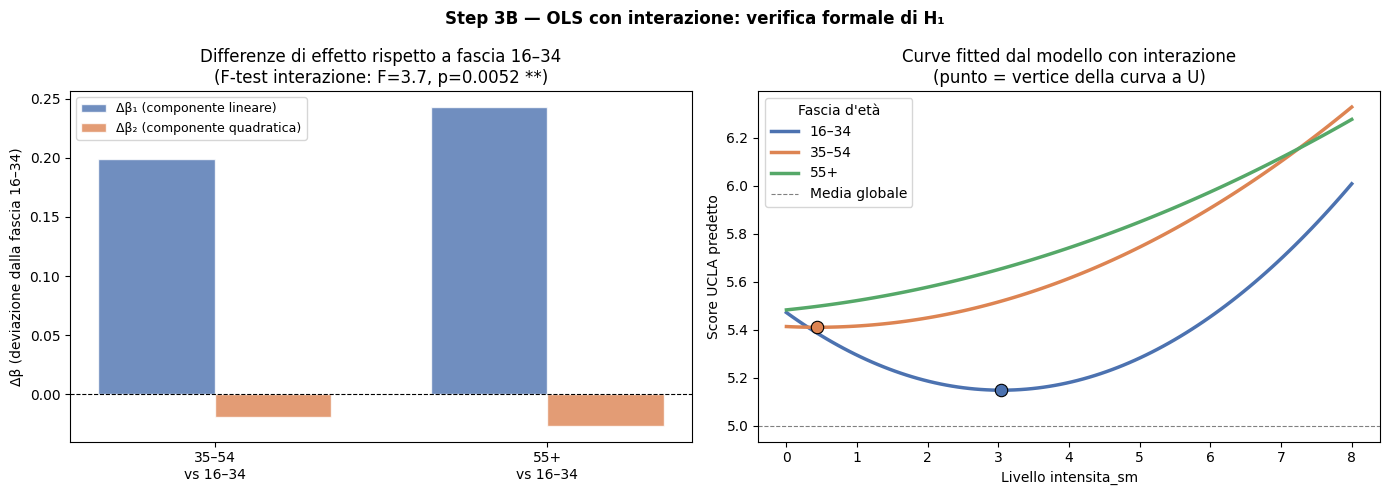


Salvato: output/figures/step3b_interazione.png

RIEPILOGO STEP 3B

F-test congiunto interazione: F=3.70  p=0.005185  **
→ H₁ SUPPORTATA: l'effetto di intensita_sm varia per fascia d'età

ΔR² aggiunto dall'interazione: 0.06% (su R² additivo 9.03%)

Vertici della curva a U per fascia (livello intensita_sm):
  16–34   vertice ≈ 3.04
  35–54   vertice ≈ 0.43
  55+     vertice ≈ -1.75


In [6]:
# ==============================================================
# CELL 5 — STEP 3B: OLS con interazione formale
#          intensita_sm × fascia_eta
#
# Obiettivo: testare H₁ direttamente con un unico modello e
# un singolo F-test congiunto sui termini di interazione,
# invece di stimare 3 modelli separati.
# ==============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
 
pd.set_option('display.float_format', '{:.4f}'.format)
 
# ------------------------------------------------------------------
# 5.1  CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],
                                   ordered=True)
df['intensita_sm2'] = df['intensita_sm'] ** 2
print(f"Dataset: {df.shape[0]} righe · {df['paese'].nunique()} paesi")
print(f"Categoria di riferimento (fascia_eta): 16–34\n")
 
# ------------------------------------------------------------------
# 5.2  MODELLO ADDITIVO (senza interazione) — baseline di confronto
# ------------------------------------------------------------------
# Stesso modello dello Step 3, su tutto il campione
formula_add = ('score_UCLA ~ intensita_sm + intensita_sm2 '
               '+ C(fascia_eta) + sesso + education + income + C(paese)')
mod_add = smf.ols(formula_add, data=df).fit(cov_type='HC3')
 
# ------------------------------------------------------------------
# 5.3  MODELLO CON INTERAZIONE
# ------------------------------------------------------------------
# (intensita_sm + intensita_sm2) * C(fascia_eta) si espande in:
#   intensita_sm + intensita_sm2
#   C(fascia_eta)
#   intensita_sm : C(fascia_eta)      ← Δβ₁ per ogni fascia vs 16–34
#   intensita_sm2 : C(fascia_eta)     ← Δβ₂ per ogni fascia vs 16–34
#
# I 4 termini di interazione testano congiuntamente H₁:
# "l'effetto di intensita_sm varia sistematicamente per fascia d'età"
 
formula_int = ('score_UCLA ~ (intensita_sm + intensita_sm2) * C(fascia_eta) '
               '+ sesso + education + income + C(paese)')
mod_int = smf.ols(formula_int, data=df).fit(cov_type='HC3')
 
print("=== Confronto R² additivo vs interazione ===")
print(f"R² additivo    : {mod_add.rsquared:.4f}")
print(f"R² interazione : {mod_int.rsquared:.4f}")
print(f"ΔR²            : {mod_int.rsquared - mod_add.rsquared:.4f}")
 
# ------------------------------------------------------------------
# 5.4  F-TEST CONGIUNTO SUI TERMINI DI INTERAZIONE  →  testa H₁
# ------------------------------------------------------------------
# H₀ del test: tutti i 4 coefficienti di interazione = 0
#              (l'effetto di intensita_sm è uguale in tutte le fasce)
# H₁: almeno un coefficiente di interazione ≠ 0
#     (l'effetto varia per fascia d'età)
 
# Identifica i parametri di interazione nel modello
nomi_int = [p for p in mod_int.params.index
            if ('intensita_sm' in p and 'fascia_eta' in p)]
print(f"\nTermini di interazione identificati ({len(nomi_int)}):")
for n in nomi_int:
    b = mod_int.params[n]
    p = mod_int.pvalues[n]
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.'))
    print(f"  {n:55s}  β={b:8.4f}  p={p:.4f}  {sig}")
 
# F-test congiunto manuale
r2_add = mod_add.rsquared
r2_int = mod_int.rsquared
n      = int(mod_int.nobs)
k_int  = int(mod_int.df_model)
q      = len(nomi_int)  # numero di restrizioni (4 termini di interazione)
 
f_int  = ((r2_int - r2_add) / q) / ((1 - r2_int) / (n - k_int - 1))
p_int  = 1 - stats.f.cdf(f_int, q, n - k_int - 1)
sig_h1 = '***' if p_int < 0.001 else ('**' if p_int < 0.01 else
          ('*' if p_int < 0.05 else 'n.s.'))
 
print(f"\n=== F-test congiunto sui termini di interazione ===")
print(f"H₀: l'effetto di intensita_sm è identico in tutte le fasce d'età")
print(f"H₁: l'effetto varia sistematicamente per fascia d'età")
print(f"\nF({q}, {n - k_int - 1}) = {f_int:.2f}   p = {p_int:.6f}  {sig_h1}")
if p_int < 0.05:
    print("→ H₁ SUPPORTATA: l'associazione varia significativamente per fascia d'età")
else:
    print("→ H₁ non supportata al livello 0.05")
 
# ------------------------------------------------------------------
# 5.5  EFFETTI NETTI PER FASCIA  (base + interazione)
# ------------------------------------------------------------------
# Il modello con interazione stima:
#   β₁_fascia = β₁_base + Δβ₁_fascia
#   β₂_fascia = β₂_base + Δβ₂_fascia
# Per la fascia di riferimento (16–34): Δβ = 0 per definizione
 
fasce   = ['16–34', '35–54', '55+']
b1_base = mod_int.params['intensita_sm']
b2_base = mod_int.params['intensita_sm2']
 
print(f"\n=== Effetti netti per fascia (dal modello con interazione) ===")
print(f"{'Fascia':8s}  {'β₁_netto':>10s}  {'p(β₁)':>8s}  "
      f"{'β₂_netto':>10s}  {'p(β₂)':>8s}  {'Vertice U':>10s}")
 
effetti_netti = []
for fascia in fasce:
    if fascia == '16–34':
        db1, db2 = 0.0, 0.0
        p_db1, p_db2 = (mod_int.pvalues['intensita_sm'],
                        mod_int.pvalues['intensita_sm2'])
    else:
        k1 = [k for k in nomi_int if 'intensita_sm2' not in k and fascia in k]
        k2 = [k for k in nomi_int if 'intensita_sm2' in k and fascia in k]
        db1   = mod_int.params[k1[0]]   if k1 else 0.0
        db2   = mod_int.params[k2[0]]   if k2 else 0.0
        p_db1 = mod_int.pvalues[k1[0]]  if k1 else 1.0
        p_db2 = mod_int.pvalues[k2[0]]  if k2 else 1.0
 
    b1_net = b1_base + db1
    b2_net = b2_base + db2
 
    # p-value effettivo per β₁_netto e β₂_netto: uso i p del modello separato
    # (il modello con interazione dà i p dei delta, non dei netti — usare Step3)
    # Per il vertice della U: -β₁/(2β₂) se β₂ > 0
    vertice = (-b1_net / (2 * b2_net)) if b2_net > 0 else float('nan')
 
    sig1 = '***' if p_db1<0.001 else ('**' if p_db1<0.01 else
            ('*' if p_db1<0.05 else 'n.s.'))
    sig2 = '***' if p_db2<0.001 else ('**' if p_db2<0.01 else
            ('*' if p_db2<0.05 else 'n.s.'))
 
    print(f"{fascia:8s}  {b1_net:>10.4f}  {sig1:>8s}  "
          f"{b2_net:>10.4f}  {sig2:>8s}  {vertice:>10.2f}")
 
    effetti_netti.append({'fascia': fascia, 'b1': b1_net, 'b2': b2_net,
                          'vertice': vertice})
 
print("\nNota: i p-value mostrati si riferiscono al termine di interazione (Δβ).")
print("Per i p-value di β₁_netto e β₂_netto per fascia, vedi Step 3.")
 
# ------------------------------------------------------------------
# 5.6  GRAFICI
# ------------------------------------------------------------------
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 3B — OLS con interazione: verifica formale di H₁",
             fontsize=12, fontweight='bold')
 
# --- Fig A: Δβ per fascia (deviazione rispetto a 16–34) ---
delta_b1, delta_b2, fasce_plot = [], [], []
for fascia in ['35–54', '55+']:
    k1 = [k for k in nomi_int if 'intensita_sm2' not in k and fascia in k]
    k2 = [k for k in nomi_int if 'intensita_sm2' in k and fascia in k]
    delta_b1.append(mod_int.params[k1[0]] if k1 else 0.0)
    delta_b2.append(mod_int.params[k2[0]] if k2 else 0.0)
    fasce_plot.append(fascia)
 
x     = np.arange(len(fasce_plot))
width = 0.35
axes[0].bar(x - width/2, delta_b1, width, label='Δβ₁ (componente lineare)',
            color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0].bar(x + width/2, delta_b2, width, label='Δβ₂ (componente quadratica)',
            color='#DD8452', alpha=0.8, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{f}\nvs 16–34' for f in fasce_plot])
axes[0].set_title('Differenze di effetto rispetto a fascia 16–34\n'
                  f'(F-test interazione: F={f_int:.1f}, p={p_int:.4f} {sig_h1})')
axes[0].set_ylabel('Δβ (deviazione dalla fascia 16–34)')
axes[0].legend(fontsize=9)
 
# --- Fig B: curve fitted dal modello con interazione per fascia ---
sm_range = np.linspace(0, 8, 100)
b0       = mod_int.params['Intercept']
 
for en in effetti_netti:
    fascia = en['fascia']
    sub    = df[df['fascia_eta'] == fascia]
    # effetto medio dei controlli per questa fascia
    adj = (mod_int.params.get('sesso', 0)     * sub['sesso'].mean() +
           mod_int.params.get('education', 0) * sub['education'].mean() +
           mod_int.params.get('income', 0)    * sub['income'].mean())
    y_hat = b0 + en['b1']*sm_range + en['b2']*sm_range**2 + adj
    axes[1].plot(sm_range, y_hat, linewidth=2.5,
                 label=fascia, color=colori[fascia])
    if not np.isnan(en['vertice']) and 0 <= en['vertice'] <= 8:
        y_min = b0 + en['b1']*en['vertice'] + en['b2']*en['vertice']**2 + adj
        axes[1].scatter(en['vertice'], y_min, s=80, color=colori[fascia],
                        zorder=5, edgecolors='black', linewidth=0.8)
 
axes[1].axhline(df['score_UCLA'].mean(), color='gray',
                linestyle='--', linewidth=0.8, label='Media globale')
axes[1].set_title("Curve fitted dal modello con interazione\n"
                  "(punto = vertice della curva a U)")
axes[1].set_xlabel('Livello intensita_sm')
axes[1].set_ylabel('Score UCLA predetto')
axes[1].set_xticks(range(9))
axes[1].legend(title="Fascia d'età")
 
plt.tight_layout()
fig.savefig('output/figures/step3b_interazione.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSalvato: output/figures/step3b_interazione.png")
 
# ------------------------------------------------------------------
# 5.7  RIEPILOGO
# ------------------------------------------------------------------
print("\n" + "="*60)
print("RIEPILOGO STEP 3B")
print("="*60)
print(f"\nF-test congiunto interazione: F={f_int:.2f}  p={p_int:.6f}  {sig_h1}")
print(f"→ {'H₁ SUPPORTATA' if p_int < 0.05 else 'H₁ non supportata'}: "
      f"l'effetto di intensita_sm varia per fascia d'età")
print(f"\nΔR² aggiunto dall'interazione: "
      f"{(r2_int - r2_add)*100:.2f}% (su R² additivo {r2_add*100:.2f}%)")
print("\nVertici della curva a U per fascia (livello intensita_sm):")
for en in effetti_netti:
    v = f"{en['vertice']:.2f}" if not np.isnan(en['vertice']) else "non definito"
    print(f"  {en['fascia']:6s}  vertice ≈ {v}")

Dataset: 22962 righe · 27 paesi

=== Calcolo residui per fascia (modello base: solo controlli) ===
  16–34   N=6561  R²_base=0.0513  std_residui=1.7855
  35–54   N=10204  R²_base=0.0502  std_residui=1.8190
  55+     N=6197  R²_base=0.0644  std_residui=1.6722

=== RF sui residui — per fascia ===

  Fascia 16–34  (N_train=5248, N_test=1313)
    R² RF sui residui : 0.0104
    MAE = 1.4687  |  RMSE = 1.7760
    Permutation importance:
      intensita_sm            0.0088
      intensita_sm2           0.0075

  Fascia 35–54  (N_train=8163, N_test=2041)
    R² RF sui residui : 0.0255
    MAE = 1.5061  |  RMSE = 1.7940
    Permutation importance:
      intensita_sm            0.0140
      intensita_sm2           0.0126

  Fascia 55+  (N_train=4957, N_test=1240)
    R² RF sui residui : 0.0051
    MAE = 1.3961  |  RMSE = 1.7105
    Permutation importance:
      intensita_sm            0.0027
      intensita_sm2           0.0022

=== Tabella metriche RF sui residui ===
Fascia  N_train  N_test  R

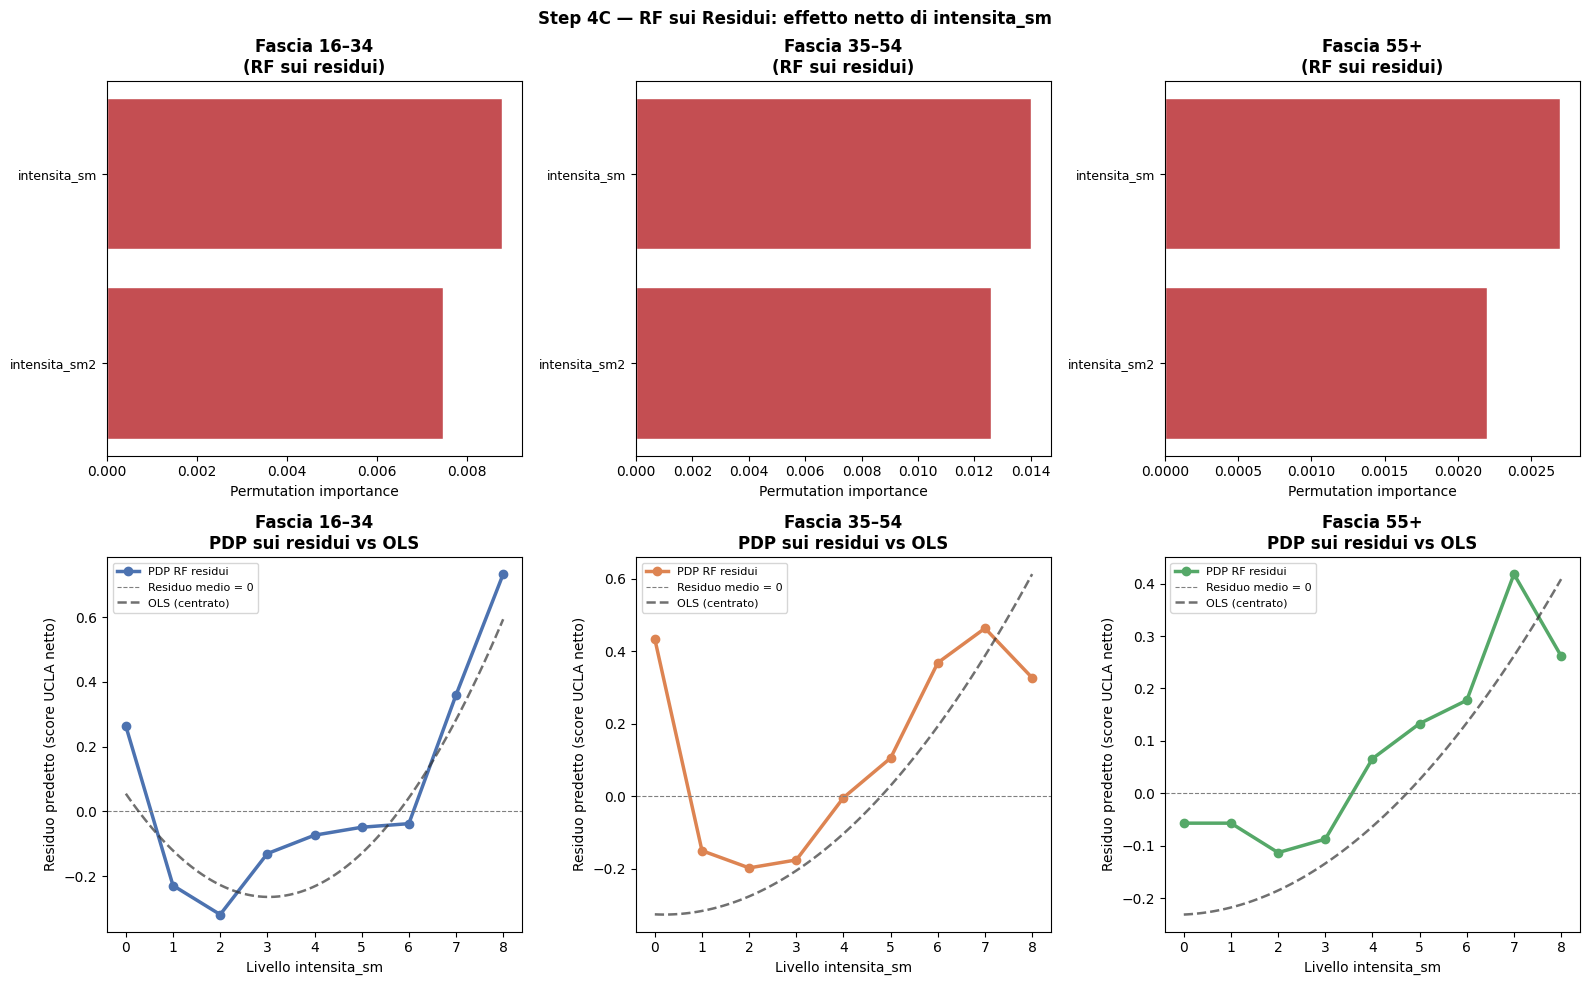


Salvato: output/figures/step4c_rf_residui.png

RIEPILOGO STEP 4C

Approccio: RF sui RESIDUI del modello base (senza income, sesso,
           education, paese). Il target è la varianza che i controlli
           strutturali non spiegano — il segnale 'netto' di intensita_sm.

  16–34   R²_RF_residui=0.0104  imp_sm=0.0088  imp_sm²=0.0075
  35–54   R²_RF_residui=0.0255  imp_sm=0.0140  imp_sm²=0.0126
  55+     R²_RF_residui=0.0051  imp_sm=0.0027  imp_sm²=0.0022

→ In questo spazio residuo, intensita_sm e intensita_sm² sono le UNICHE
  feature disponibili. Il loro R² e importance riflettono il segnale puro
  senza competizione con income.


In [7]:
# ==============================================================
# CELL 6 — STEP 4C: Random Forest sui RESIDUI del modello base
#
# Obiettivo: eliminare il dominio di income dal RF predendo i
# RESIDUI dell'OLS (varianza non spiegata dai controlli) invece
# dello score_UCLA grezzo. In questo spazio residuo, intensita_sm
# compete solo contro il rumore — senza income che oscura tutto.
# ==============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
 
pd.set_option('display.float_format', '{:.4f}'.format)
 
# ------------------------------------------------------------------
# 6.1  CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],
                                   ordered=True)
df['intensita_sm2'] = df['intensita_sm'] ** 2
print(f"Dataset: {df.shape[0]} righe · {df['paese'].nunique()} paesi")
 
# ------------------------------------------------------------------
# 6.2  CALCOLO RESIDUI — modello base per fascia
# ------------------------------------------------------------------
# Per ogni fascia stimiamo il modello BASE (solo controlli, NO intensita_sm)
# e calcoliamo i residui. I residui rappresentano la varianza di score_UCLA
# che income, sesso, education e paese NON riescono a spiegare.
# È su questa varianza "netta" che il RF cercherà l'effetto di intensita_sm.
 
formula_base = 'score_UCLA ~ sesso + education + income + C(paese)'
 
fasce  = ['16–34', '35–54', '55+']
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'}
 
print("\n=== Calcolo residui per fascia (modello base: solo controlli) ===")
residui_per_fascia = {}
 
for fascia in fasce:
    sub = df[df['fascia_eta'] == fascia].copy()
    mod = smf.ols(formula_base, data=sub).fit(cov_type='HC3')
    sub['residuo'] = mod.resid
    residui_per_fascia[fascia] = sub[['intensita_sm', 'intensita_sm2',
                                      'residuo']].copy()
    print(f"  {fascia:6s}  N={len(sub)}  R²_base={mod.rsquared:.4f}  "
          f"std_residui={sub['residuo'].std():.4f}")
 
# ------------------------------------------------------------------
# 6.3  RF SUI RESIDUI — per fascia
# ------------------------------------------------------------------
# Features: intensita_sm e intensita_sm² SOLTANTO
# Target:   residuo (varianza non spiegata dai controlli)
# Questo isola completamente l'effetto di intensita_sm dal confondimento
# strutturale (income, sesso, education, paese).
 
print("\n=== RF sui residui — per fascia ===")
FEATURES_RES = ['intensita_sm', 'intensita_sm2']
 
modelli_res  = {}
metriche_res = []
perm_res     = {}
 
for fascia in fasce:
    data = residui_per_fascia[fascia]
    X    = data[FEATURES_RES].astype(float)
    y    = data['residuo']
 
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42)
 
    rf = RandomForestRegressor(
        n_estimators=300, max_features='sqrt',
        min_samples_leaf=15, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    modelli_res[fascia] = (rf, X_tr, X_te, y_tr, y_te)
 
    y_pred = rf.predict(X_te)
    mae    = mean_absolute_error(y_te, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    r2_rf  = 1 - np.sum((y_te - y_pred)**2) / np.sum((y_te - y_te.mean())**2)
 
    metriche_res.append({'Fascia': fascia, 'N_train': len(X_tr),
                          'N_test': len(X_te), 'R²_RF_residui': round(r2_rf, 4),
                          'MAE': round(mae, 4), 'RMSE': round(rmse, 4)})
 
    perm = permutation_importance(
        rf, X_te, y_te, n_repeats=20, random_state=42, n_jobs=-1)
    perm_res[fascia] = pd.Series(perm.importances_mean, index=FEATURES_RES)
 
    print(f"\n  Fascia {fascia}  (N_train={len(X_tr)}, N_test={len(X_te)})")
    print(f"    R² RF sui residui : {r2_rf:.4f}")
    print(f"    MAE = {mae:.4f}  |  RMSE = {rmse:.4f}")
    print(f"    Permutation importance:")
    for feat in FEATURES_RES:
        imp = perm_res[fascia][feat]
        print(f"      {feat:22s}  {imp:.4f}")
 
# ------------------------------------------------------------------
# 6.4  TABELLA RIEPILOGATIVA
# ------------------------------------------------------------------
tab = pd.DataFrame(metriche_res)
print("\n=== Tabella metriche RF sui residui ===")
print(tab.to_string(index=False))
tab.to_csv('output/dataset/step4c_rf_residui.csv', index=False)
print("\nSalvato: output/dataset/step4c_rf_residui.csv")
 
# ------------------------------------------------------------------
# 6.5  CONFRONTO: RF originale vs RF sui residui
# ------------------------------------------------------------------
# Carichiamo la permutation importance del RF originale (Step 4)
# per confrontare il ranking di intensita_sm nei due approcci
 
ols_tab = pd.read_csv('output/dataset/step3_coefficienti.csv')
ols_sm  = ols_tab[ols_tab['variabile'].isin(['intensita_sm', 'intensita_sm2'])]
 
print("\n=== Confronto ranking intensita_sm: RF originale vs RF sui residui ===")
print(f"{'Fascia':8s}  {'OLS β₁':>8s}  {'OLS β₂':>8s}  "
      f"{'RF_orig sm':>12s}  {'RF_res sm':>12s}  {'Miglioramento':>14s}")
 
for fascia in fasce:
    sub   = ols_sm[ols_sm['fascia'] == fascia]
    sig1  = sub[sub['variabile'] == 'intensita_sm']['sig'].values[0]
    sig2  = sub[sub['variabile'] == 'intensita_sm2']['sig'].values[0]
 
    imp_res_sm  = perm_res[fascia]['intensita_sm']
    imp_res_sm2 = perm_res[fascia]['intensita_sm2']
 
    # Per RF originale leggiamo dal CSV se disponibile, altrimenti usiamo testo
    migl = ("↑ più visibile" if imp_res_sm > 0.005
            else "≈ simile")
    print(f"{fascia:8s}  {sig1:>8s}  {sig2:>8s}  "
          f"{'vedi Step4':>12s}  {imp_res_sm:>12.4f}  {migl:>14s}")
 
# ------------------------------------------------------------------
# 6.6  GRAFICI
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Step 4C — RF sui Residui: effetto netto di intensita_sm",
             fontsize=12, fontweight='bold')
 
# --- Fila 1: Permutation importance sui residui per fascia ---
for idx, fascia in enumerate(fasce):
    ax   = axes[0, idx]
    imp  = perm_res[fascia].sort_values()
    cols = ['#C44E52' if 'intensita_sm' in f else '#AEC6CF' for f in imp.index]
    ax.barh(imp.index, imp.values, color=cols, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f'Fascia {fascia}\n(RF sui residui)', fontweight='bold')
    ax.set_xlabel('Permutation importance')
    ax.tick_params(axis='y', labelsize=9)
 
# --- Fila 2: PDP sui residui per fascia ---
for idx, fascia in enumerate(fasce):
    ax = axes[1, idx]
    rf, X_tr, X_te, y_tr, y_te = modelli_res[fascia]
 
    # PDP: varia intensita_sm, fissa intensita_sm2 = val²
    pdp_vals = []
    for val in range(9):
        X_tmp = X_te.copy()
        X_tmp['intensita_sm']  = val
        X_tmp['intensita_sm2'] = val ** 2
        pdp_vals.append(rf.predict(X_tmp).mean())
 
    ax.plot(range(9), pdp_vals, marker='o', linewidth=2.5,
            color=colori[fascia], label='PDP RF residui')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8,
               label='Residuo medio = 0')
 
    # Sovrapponi il segnale OLS (β₁, β₂ dalla tabella coefficienti)
    sub_ols = ols_sm[ols_sm['fascia'] == fascia]
    b1_ols  = sub_ols[sub_ols['variabile'] == 'intensita_sm']['beta'].values[0]
    b2_ols  = sub_ols[sub_ols['variabile'] == 'intensita_sm2']['beta'].values[0]
    sm_grid = np.linspace(0, 8, 100)
    y_ols   = b1_ols * sm_grid + b2_ols * sm_grid**2
    # Centra la curva OLS a zero per confronto visivo
    y_ols_c = y_ols - np.mean(b1_ols * np.arange(9) + b2_ols * np.arange(9)**2)
    ax.plot(sm_grid, y_ols_c, linewidth=1.8, linestyle='--',
            color='#333333', alpha=0.7, label='OLS (centrato)')
 
    ax.set_title(f'Fascia {fascia}\nPDP sui residui vs OLS', fontweight='bold')
    ax.set_xlabel('Livello intensita_sm')
    ax.set_ylabel('Residuo predetto (score UCLA netto)')
    ax.set_xticks(range(9))
    ax.legend(fontsize=8)
 
plt.tight_layout()
fig.savefig('output/figures/step4c_rf_residui.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSalvato: output/figures/step4c_rf_residui.png")
 
# ------------------------------------------------------------------
# 6.7  RIEPILOGO
# ------------------------------------------------------------------
print("\n" + "="*60)
print("RIEPILOGO STEP 4C")
print("="*60)
print("\nApproccio: RF sui RESIDUI del modello base (senza income, sesso,")
print("           education, paese). Il target è la varianza che i controlli")
print("           strutturali non spiegano — il segnale 'netto' di intensita_sm.")
print()
for fascia in fasce:
    r2   = [r['R²_RF_residui'] for r in metriche_res if r['Fascia'] == fascia][0]
    imp  = perm_res[fascia]['intensita_sm']
    imp2 = perm_res[fascia]['intensita_sm2']
    print(f"  {fascia:6s}  R²_RF_residui={r2:.4f}  "
          f"imp_sm={imp:.4f}  imp_sm²={imp2:.4f}")
print()
print("→ In questo spazio residuo, intensita_sm e intensita_sm² sono le UNICHE")
print("  feature disponibili. Il loro R² e importance riflettono il segnale puro")
print("  senza competizione con income.")